# Exercise 2: CNN Performance vs Signal-to-Noise Ratio

We study the performance of the CNN by varying the amplitude **A** of the patterns
while keeping **DX** fixed, i.e. changing the **signal-to-noise ratio SNR = A / DX**.

The 3-class problem:
- **Class 0**: pure random walk (no pattern)
- **Class 1**: random walk + positive bump of amplitude A over Z bins
- **Class 2**: random walk + negative bump of amplitude A over Z bins

As A increases (higher SNR), patterns become more visible and classification should become easier.

First of all, let's import all the needed libraries

In [17]:
import numpy as np
import pandas as pd
from tensorflow import data
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 14


import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from sklearn.model_selection import train_test_split

%run plot.py

In [18]:
def preprocess(x, y, train_size=0.8, random_state=None) -> tuple:
    """
    Splits data into training and validation sets, removes the per-sample mean,
    and normalizes using the average standard deviation of the training set.

    Args:
        x (np.ndarray): Features array of shape (N_samples, L_timesteps).
        y (np.ndarray): Labels array of shape (N_samples,).
        train_size (float, optional): Proportion of the dataset to include in the training split. Defaults to 0.8.
        random_state (int, optional): Seed for reproducible shuffles. Defaults to None.

    Returns:
        tuple: (x_train, y_train, x_val, y_val) formatted as 3D tensors (samples, timesteps, channels)
               ready to be fed into Keras/TensorFlow Conv1D layers.
    """

    x_train, x_val, y_train, y_val = train_test_split(x, y, train_size=train_size, random_state=random_state)

    # Vectorially normalizing train and val sets
    xm_train, xm_val = x_train.mean(axis=1, keepdims=True), x_val.mean(axis=1, keepdims=True)
    std_train, std_val = x_train.std(axis=1), x_val.std(axis=1)
    x_train = (x_train - xm_train) / std_train.mean()
    x_val = (x_val - xm_val) / std_val.mean()


    # Necessary reshape for keras
    x_train = x_train.reshape(x_train.shape[0], L, 1)
    x_val = x_val.reshape(x_val.shape[0], L, 1)

    return x_train, y_train, x_val, y_val


## CNN model

We use the same CNN architecture as in the lecture notebook (Model 1):
- Conv1D → AveragePooling1D → Conv1D → Flatten → Dense → Dropout → Dense(softmax)

In [19]:
def build_model(L=60, n_class=3) -> tf.keras.Model:
    """
    Build and compile the CNN (same architecture as the lecture notebook).
    Args:
        L (int): Length of the input sequence.
        n_class (int): Number of classes.
    Returns:
        model (tf.keras.Model): Compiled CNN model.
    """
    input_shape = (L, 1)
    ini = tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.05, seed=None)

    model = Sequential([
        Conv1D(filters=5, kernel_size=11, activation='relu',
        kernel_initializer=ini, input_shape=input_shape),
        AveragePooling1D(pool_size=5),
        Conv1D(filters=5, kernel_size=7, activation='relu'),
        Flatten(),
        Dense(12, activation='relu'),
        Dropout(0.5),
        Dense(n_class, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Quick check
m = build_model()
m.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_30 (Conv1D)              │ (None, 50, 5)          │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_15            │ (None, 10, 5)          │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_31 (Conv1D)              │ (None, 4, 5)           │           180 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 12)             │           252 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 3)              │            39 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 531 (2.07 KB)

 Trainable params: 531 (2.07 KB)

 Non-trainable params: 0 (0.00 B)

# Read data

In [20]:
str0 = 'ts_L60_Z12_A500_DX50_bias5_N10000.dat'
fnamex='DATA/x_'+str0
fnamey='DATA/y_'+str0

x = np.loadtxt(fnamex, delimiter=" ",dtype=float)
# N = Number of samples, L = Number of features
N, L = len(x), len(x[0])

categ = np.loadtxt(fnamey, dtype=int)
n_class = 3

y = np.zeros((N,n_class))
for i in range(N):
    y[i][categ[i]] = 1. # y contains one-hot encoding

## SNR study: sweep over amplitude A

For each value of A we:
1. Pre-process (mean removal + normalisation)
2. Train the CNN
3. Record the best validation accuracy

In [21]:
# Fixed parameters
L       = 60
Z       = 12
DX      = 50      # noise level – kept fixed
bias    = 5
N       = 10000
n_class = 3

# Amplitude values to scan (SNR = A / DX)
A_values = [0, 50, 100, 150, 200, 250, 300, 400, 500, 700, 1000]

EPOCHS     = 30
BATCH_SIZE = 128

val_accuracies = []

for A in A_values:
    snr = A / DX
    print(f"A = {A} \t SNR = A/DX = {snr:.2f}")

    # 1. Pre-process
    x_train, y_train, x_val, y_val = preprocess(x, y)

    # 2. Build a fresh model
    model = build_model(L=L, n_class=n_class)

    # 3. Train
    history = model.fit(
        x_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_data=(x_val, y_val),
        verbose=0          # set to 1 if you want epoch-by-epoch output
    )

    # 4. Record best validation accuracy
    best_val_acc = max(history.history['val_accuracy'])
    val_accuracies.append(best_val_acc)
    print(f"Best val accuracy: {best_val_acc:.4f}\n")


# Saving results to an external CSV
snr_values = [A / DX for A in A_values]
results_df = pd.DataFrame({
    'Amplitude_A': A_values,
    'SNR': snr_values,
    'Best_Val_Accuracy': val_accuracies
})
csv_filename = 'cnn_snr_results.csv'
results_df.to_csv(csv_filename, index=False)

A = 0 	 SNR = A/DX = 0.00
Best val accuracy: 0.9645

A = 50 	 SNR = A/DX = 1.00
Best val accuracy: 0.9450

A = 100 	 SNR = A/DX = 2.00
Best val accuracy: 0.9710

A = 150 	 SNR = A/DX = 3.00
Best val accuracy: 0.9770

A = 200 	 SNR = A/DX = 4.00
Best val accuracy: 0.9755

A = 250 	 SNR = A/DX = 5.00
Best val accuracy: 0.9795

A = 300 	 SNR = A/DX = 6.00
Best val accuracy: 0.9765

A = 400 	 SNR = A/DX = 8.00
Best val accuracy: 0.9770

A = 500 	 SNR = A/DX = 10.00
Best val accuracy: 0.9730

A = 700 	 SNR = A/DX = 14.00
Best val accuracy: 0.9765

A = 1000 	 SNR = A/DX = 20.00
Best val accuracy: 0.9595



## Results: accuracy vs SNR

We provide two graphs:

* **Accuracy vs Amplitude**
* **Accuracy vs SNR**

In both of them there is the best accuracy value of the CNN compared to a random guess (accuracy 1/n_class)

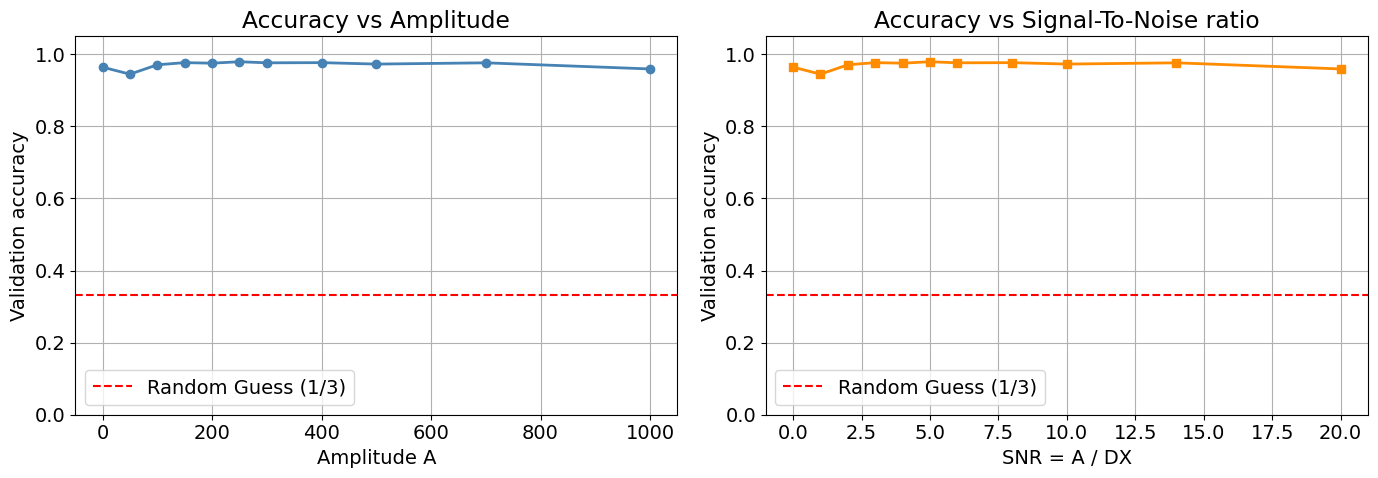

In [24]:
snr_values = [A / DX for A in A_values]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: accuracy vs amplitude
ax = axes[0]
ax.plot(A_values, val_accuracies, 'o-', color='steelblue', linewidth=2)
ax.axhline(1/3, color='red', linestyle='--', label=f'Random Guess (1/{n_class})')
ax.set_xlabel('Amplitude A')
ax.set_ylabel('Validation accuracy')
ax.set_title('Accuracy vs Amplitude')
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(True)

# Right panel: accuracy vs SNR 
ax = axes[1]
ax.plot(snr_values, val_accuracies, 's-', color='darkorange', linewidth=2)
ax.axhline(1/n_class, color='red', linestyle='--', label=f'Random Guess (1/{n_class})')
ax.set_xlabel('SNR = A / DX')
ax.set_ylabel('Validation accuracy')
ax.set_title('Accuracy vs Signal-To-Noise ratio')
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig('cnn_accuracy_vs_snr.png', dpi=120)
plt.show()